In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import base64

from functools import reduce
from urllib.parse import urlencode, urlunparse,quote, quote_plus


In [10]:
def read_cred():
    f = open("../../../cred.txt", "r")
    cred = f.read()
    f.close()
    return cred
urlBase = 'https://oianalytics-100.optimistik.fr/api/oianalytics/time-values/query?'
credentials = read_cred()

In [11]:
def get_OI(url,start,end,interval='PT1M',tag='xx',auth='xx',hS='00',hF='23'):
	url_all =url+'data-reference='+tag+'&aggregation=TIME'+'&aggregation-function=MEAN'+"&from="+start+"T"+hS+"%3A00%3A00.000Z&to="+end+"T"+hF+"%3A59%3A59.000Z&aggregation-period="+interval
	#print(url_all,auth)
	d_data = pd.read_json(url_all,storage_options={ 'Authorization': 'basic '+ auth})
	# print(d_data['values'][0])
	arr = np.asarray(np.asarray(d_data['values'])[0])
	return d_data['values'][0]

In [12]:
def get_data(tags,start, end):
    liste = list(range(0))
    for tag in tags:
        urlTag = quote(tag, safe=':/?#[]@!$&\'()*+,;=')
        data = get_OI(urlBase,start,end,'PT20M',urlTag,credentials,'00','23')
        df = pd.DataFrame(data)
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.set_index('timestamp')
        df = df.rename(columns={'value':tag})
        liste.append(df)
    return liste

In [13]:
def merge_data(liste):
    df = reduce(lambda left,right : pd.merge(left, right,left_index=True,right_index=True,how='outer'),liste)
    return df

In [14]:
def detecter_campagnes(df, seuil_jours=30):
    """
    Détecte les campagnes et ajoute plusieurs colonnes d'information
    """
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
    
    df = df.sort_index()
    
    # Calculer les différences
    diff_jours = df.index.to_series().diff().dt.days
    
    # Détecter les nouvelles campagnes
    nouvelle_campagne = (diff_jours > seuil_jours) | (diff_jours.isna())
    
    # Numéro de campagne
    df['campagne'] = nouvelle_campagne.cumsum()
    
    # Date de début de chaque campagne
    df['debut_campagne'] = df.groupby('campagne').apply(lambda x: x.index.min()).loc[df['campagne']].values
    
    # Nombre de jours depuis le début de la campagne
    df['jour_campagne'] = (df.index - df['debut_campagne']).days
    
    return df


In [96]:
def detecter_campagnes_v2(df, seuil_jours=3):
    df = df.sort_index().copy()

    # Calcul de l'écart de temps entre deux points consécutifs
    deltas = df.index.to_series().diff()

    # Nouvelle campagne si delta > seuil_jours
    nouvelle_campagne = deltas > pd.Timedelta(days=seuil_jours)

    # Numérotation : on cumule les True
    df["campagne"] = nouvelle_campagne.cumsum() + 1

    # Ajout colonne mois-année au format mm-aa
    df["mois_annee"] = df.index.strftime("%y-%m")
    df["mois_annee_dt"] = pd.to_datetime(df.index.to_period('M').astype(str))
    #df["mois_annee_dt"] = pd.to_datetime(df["mois_annee"], format="%m-%y")

    return df

In [33]:
tags = ['CTY_A1000M_Poids container','CTY_A1000M_Teneur arr. Vit. A (UV)','CTY_A1000M_Titre VA AC']; #,'CTY_FHA1000M_Teneur_VA']
start = '2010-01-01'
end = '2025-11-29'
df_list = get_data(tags,start,end)
data = merge_data(df_list)
brute = data.copy()
brute.describe()

,CTY_A1000M_Poids container,CTY_A1000M_Teneur arr. Vit. A (UV),CTY_A1000M_Titre VA AC
count,13817.000000,3.588730e+05,3.291270e+05
mean,1062.344597,1.033946e+06,1.018705e+06
std,90.454573,5.540244e+04,1.103427e+05
min,5.000000,0.000000e+00,0.000000e+00
25%,1022.000000,1.019000e+06,1.000000e+06
50%,1070.000000,1.036000e+06,1.025000e+06
75%,1109.000000,1.048000e+06,1.045000e+06
max,2585.428571,1.027070e+07,9.794000e+06


In [17]:
def filtering(df):
    df = df.dropna()
    df = df[(df['CTY_A1000M_Poids container']>700) & (df['CTY_A1000M_Poids container']<1300)]
    df = df[(df['CTY_A1000M_Teneur arr. Vit. A (UV)']>800_000) & (df['CTY_A1000M_Teneur arr. Vit. A (UV)']<1_300_000)]
    df = df[(df['CTY_A1000M_Titre VA AC']>700_000) & (df['CTY_A1000M_Titre VA AC']<1_300_000)]
    return df

In [18]:
def plot_data(liste, tags):
    for tag in tags:
        plt.figure(figsize=(18,6))
        
        # Calcul de la moyenne et de la médiane
        moyenne = liste[tag].mean()
        mediane = liste[tag].median()
        
        # Subplot 1 : Scatter plot
        plt.subplot(121)
        plt.scatter(liste.index, liste[tag], label=tag, c='b', alpha=0.3)
        
        # Lignes horizontales pour moyenne et médiane
        plt.axhline(y=moyenne, color='red', linestyle='--', linewidth=1, label=f'Moyenne: {moyenne:.2f}')
        plt.axhline(y=mediane, color='violet', linestyle='--', linewidth=1, label=f'Médiane: {mediane:.2f}')
        
        plt.legend()
        
        # Subplot 2 : Histogramme
        plt.subplot(122)
        sns.histplot(liste[tag], label=tag, kde=True, common_norm=True)
        
        # Lignes verticales pour moyenne et médiane dans l'histogramme
        plt.axvline(x=moyenne, color='red', linestyle='--', linewidth=2, label=f'Moyenne: {moyenne:.2f}')
        plt.axvline(x=mediane, color='violet', linestyle='--', linewidth=2, label=f'Médiane: {mediane:.2f}')
        
        plt.legend()

In [19]:
def ajoute_cumul(df):
    """
    Ajoute deux colonnes au dataframe :
    - cumul_UV : (colonne 0 * colonne 1) / 1_000_000
    - cumul_Labo : (colonne 0 * colonne 2) / 1_000_000
    
    Parameters:
    df : DataFrame pandas
    
    Returns:
    DataFrame avec les nouvelles colonnes
    """
    df['cumul_UV'] = (df.iloc[:, 0] * df.iloc[:, 1]) / 1_000_000
    df['cumul_Labo'] = (df.iloc[:, 0] * df.iloc[:, 2]) / 1_000_000
    
    return df

In [20]:
def ajouter_moyennes_glissantes(df, window=10):
    """
    Ajoute deux colonnes de moyennes pondérées glissantes :
    - cumul_UV : moyenne pondérée de la colonne 2 par la colonne 1 sur les 10 dernières valeurs
    - cumul_Labo : moyenne pondérée de la colonne 3 par la colonne 1 sur les 10 dernières valeurs
    
    Parameters:
    df : DataFrame pandas
    window : int, nombre de valeurs pour la fenêtre glissante (défaut: 10)
    
    Returns:
    DataFrame avec les nouvelles colonnes
    """
    # Extraction des colonnes
    poids = df.iloc[:, 0]
    valeurs_uv = df.iloc[:, 1]
    valeurs_labo = df.iloc[:, 2]
    
    # Calcul de la moyenne pondérée glissante pour UV
    numerateur_uv = (poids * valeurs_uv).rolling(window=window).sum()
    denominateur = poids.rolling(window=window).sum()
    df['cumul_UV'] = numerateur_uv / denominateur
    
    # Calcul de la moyenne pondérée glissante pour Labo
    numerateur_labo = (poids * valeurs_labo).rolling(window=window).sum()
    df['cumul_Labo'] = numerateur_labo / denominateur
    
    return df

# Utilisation
# brute = ajouter_moyennes_glissantes(brute, window=10)

In [100]:
def resume_par_campagne(df):
    # On suppose que df contient déjà la colonne "campagne"
    # et que les colonnes sont : Poids, UV, labo, teneur

    # UV pondéré = somme(Poids * UV) / somme(Poids)
    df["UV_pondere"] = df["CTY_A1000M_Poids container"] * df["CTY_A1000M_Teneur arr. Vit. A (UV)"]

    grouped = df.groupby(["campagne","mois_annee","mois_annee_dt"]).agg(
        nb_lots=("CTY_A1000M_Poids container", "count"),
        poids_total=("CTY_A1000M_Poids container", "sum"),
        uv_pondere=("UV_pondere", lambda x: x.sum() / df.loc[x.index, "CTY_A1000M_Poids container"].sum())
    )

    return grouped.reset_index()

In [136]:
def plot_campagnes(resume):
    resume = resume.sort_values("mois_annee_dt")
    print("nb elemtnts resume:", len(resume))
    plt.figure(figsize=(12, 6))

    # Barres : nombre de lots
    ax = sns.barplot(
        data=resume,
        x="mois_annee",
        y="nb_lots",
        color="skyblue",
        label="# lots"
    )

    # Deuxième axe pour UV pondéré
    ax2 = ax.twinx()
    sns.lineplot(
        data=resume,
        x="mois_annee",
        y="uv_pondere",
        marker="o",
        color="red",
        linewidth=2,
        ax=ax2,
        label="UV pondéré"
    )

    # Axe X vertical + petite police
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6)

    # Titres et labels
    ax.set_xlabel("Mois-année")
    ax.set_ylabel("Nb lots", fontsize=8)
    ax2.set_ylabel("UV pondéré", fontsize=8)

    # Légendes combinées (police réduite)
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=6)

    plt.title("Lots et UV pondéré par mois-année", fontsize=10)

    plt.tight_layout()
    plt.show()

/var/folders/vw/2g_98rts7tzczmvh5hqt_qn00000gn/T/ipykernel_78925/2669702157.py:15: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["mois_annee_dt"] = pd.to_datetime(df.index.to_period('M').astype(str))


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12189 entries, 2013-05-12 23:00:00+00:00 to 2025-11-20 18:00:00+00:00
Data columns (total 8 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   CTY_A1000M_Poids container          12189 non-null  float64       
 1   CTY_A1000M_Teneur arr. Vit. A (UV)  12189 non-null  float64       
 2   CTY_A1000M_Titre VA AC              12189 non-null  float64       
 3   cumul_UV                            11990 non-null  float64       
 4   cumul_Labo                          11990 non-null  float64       
 5   campagne                            12189 non-null  int64         
 6   mois_annee                          12189 non-null  object        
 7   mois_annee_dt                       12189 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 857.0+ KB
None


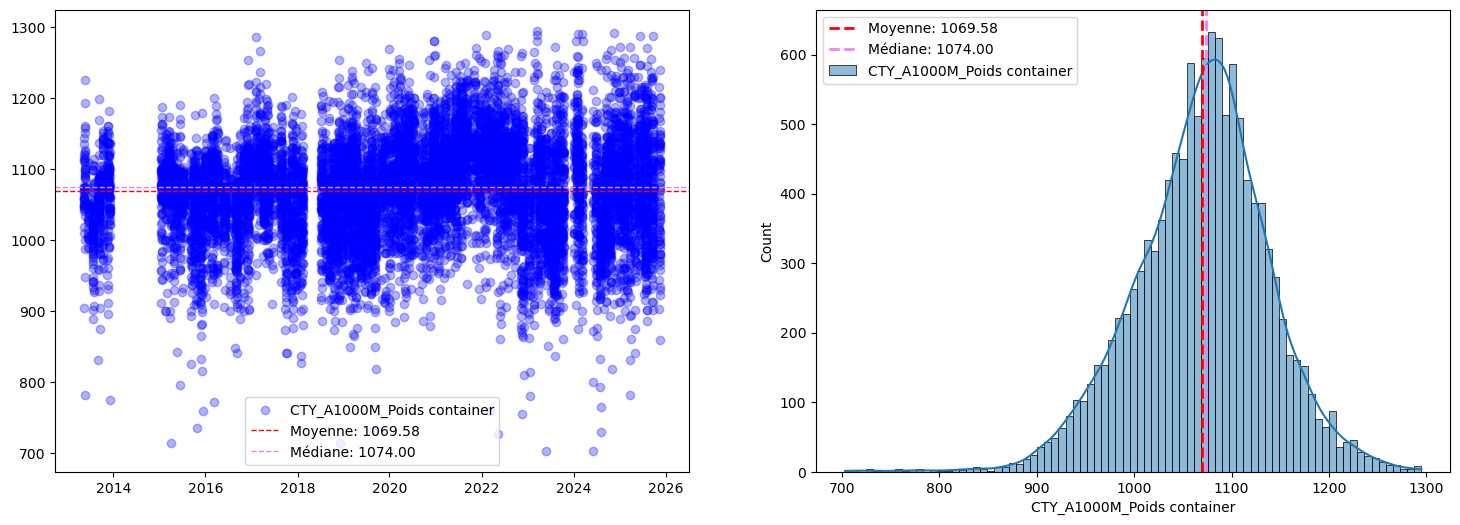

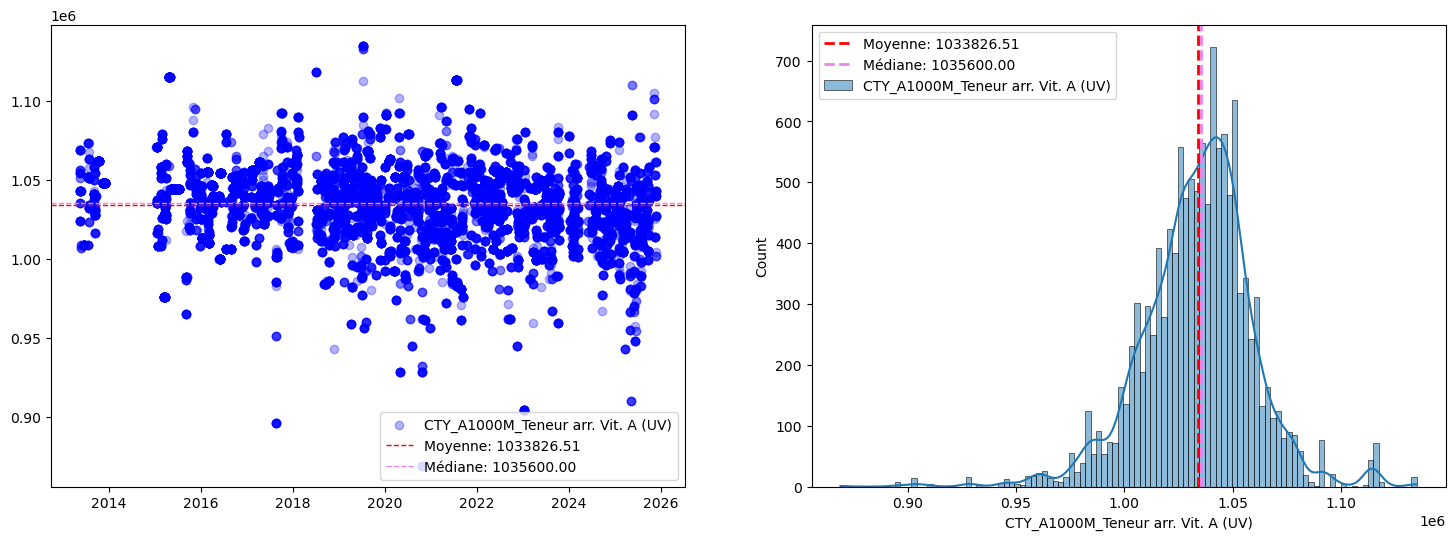

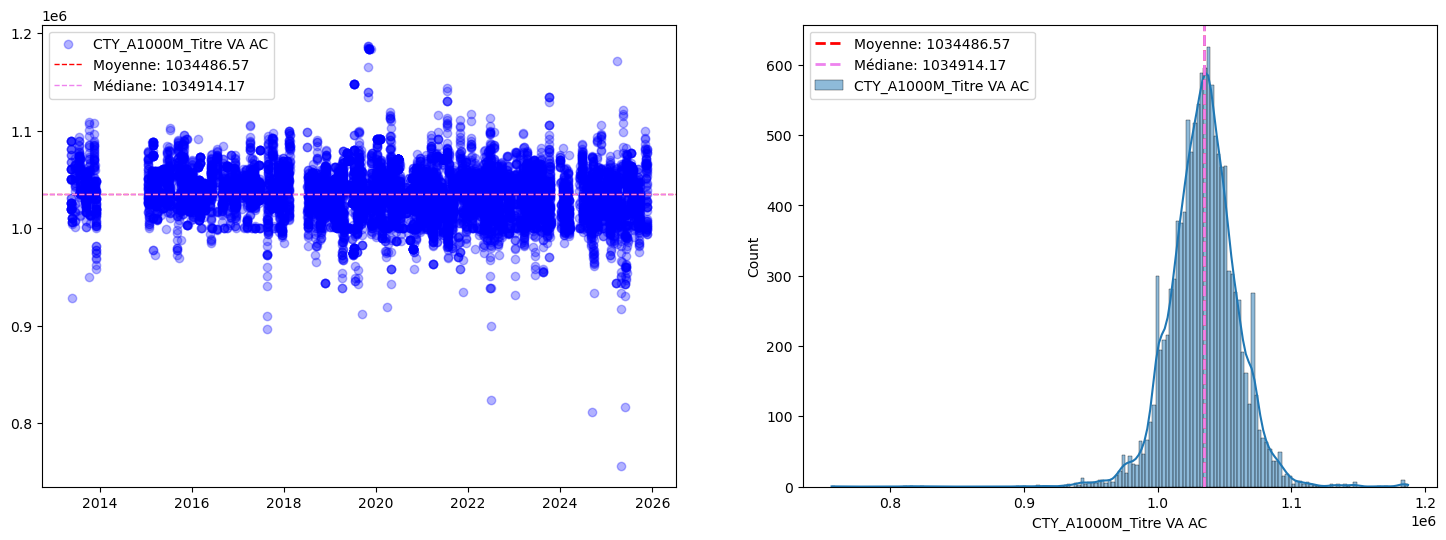

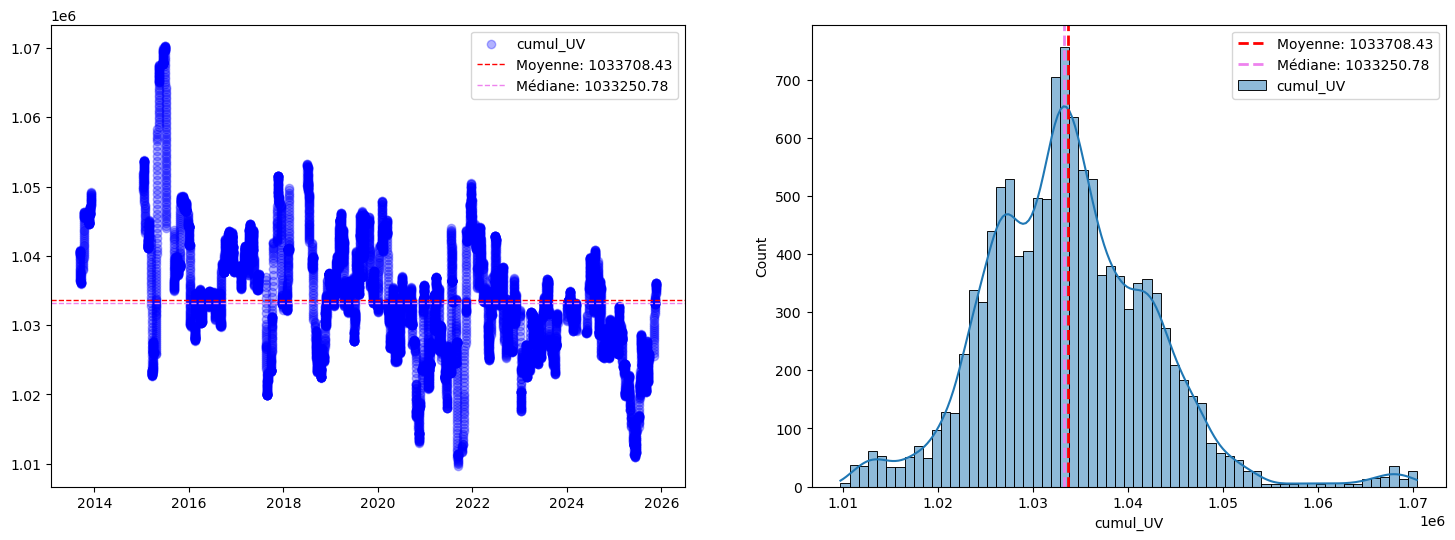

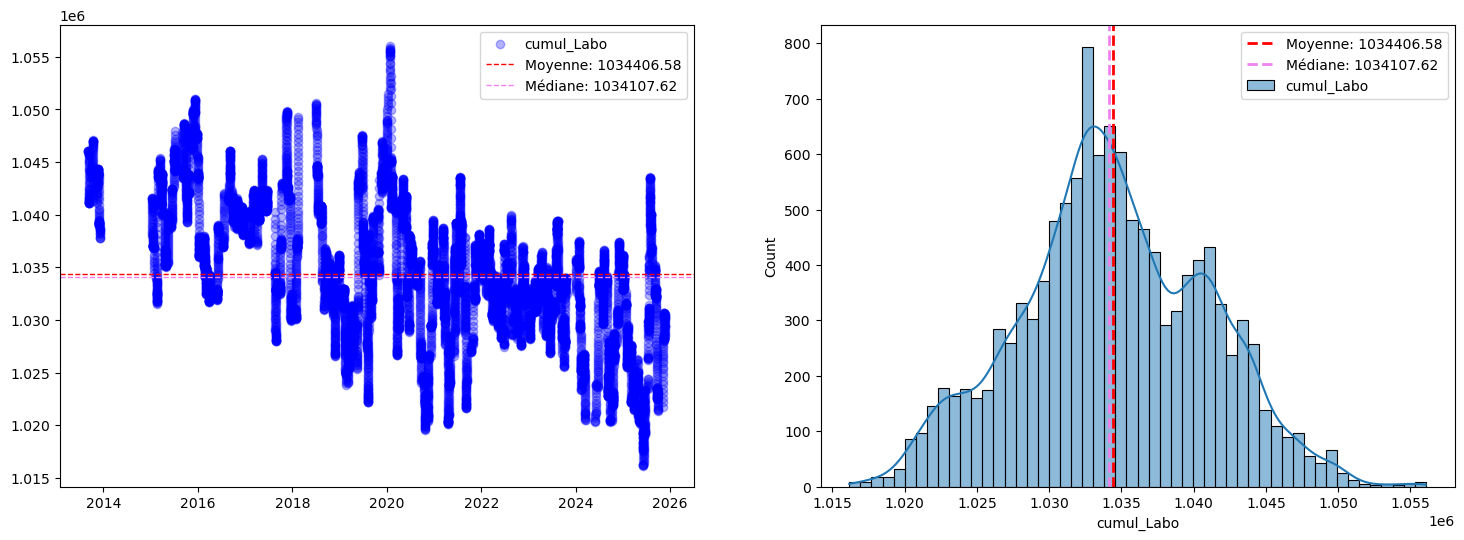

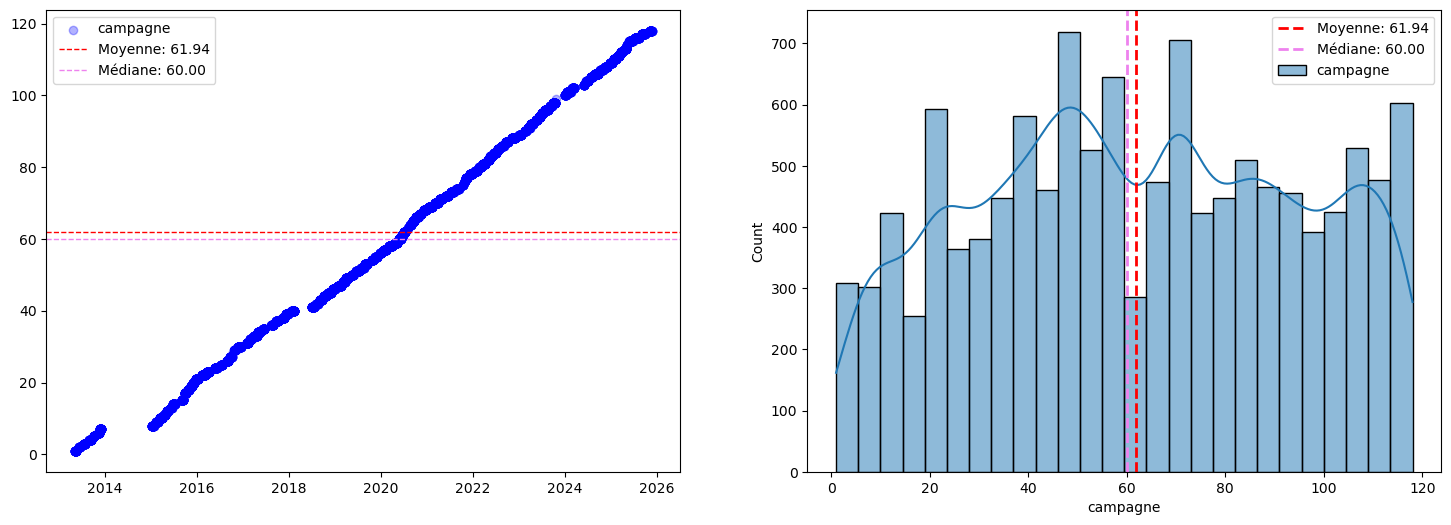

In [138]:
result = brute.copy()
result = filtering(result)
result = ajouter_moyennes_glissantes(result,200)
result = detecter_campagnes_v2(result, seuil_jours=5)
print(result.info())
tags_ = result.columns.tolist()[:-2]
plot_data(result, tags_)

In [ ]:

plot_data(result, tags_)


In [139]:
campagnes = resume_par_campagne(result)
campagnes

,campagne,mois_annee,mois_annee_dt,nb_lots,poids_total,uv_pondere
0,1,13-05,2013-05-01,59,63341.000000,1.042808e+06
1,2,13-06,2013-06-01,25,25658.500000,1.009000e+06
2,3,13-07,2013-07-01,80,81227.000000,1.046182e+06
3,4,13-09,2013-09-01,97,101249.666667,1.037483e+06
4,5,13-10,2013-10-01,47,50378.000000,1.062000e+06
...,...,...,...,...,...,...
169,115,25-06,2025-06-01,126,137849.200000,1.019075e+06
170,116,25-07,2025-07-01,143,151906.500000,1.027413e+06
171,116,25-08,2025-08-01,65,70136.000000,1.017966e+06
172,117,25-09,2025-09-01,158,168782.000000,1.027848e+06


In [140]:
def plot_campagnes_v2(resume):
    # Tri par campagne
    resume = resume.sort_values("mois_annee_dt")
    print("nb elemtnts resume:", len(resume))

    plt.figure(figsize=(12, 6))

    # Barres : nombre de lots
    ax = sns.barplot(
        data=resume,
        x="mois_annee",
        y="nb_lots",
        color="skyblue",
        label="# lots"
    )

    # Ligne UV pondéré
    ax2 = ax.twinx()
    sns.lineplot(
        data=resume,
        x="mois_annee",
        y="uv_pondere",
        marker="o",
        color="red",
        linewidth=2,
        ax=ax2,
        label="UV pondéré"
    )

    # Format date sur l'axe X
#    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y-%m"))
    ax.set_xticks(range(len(resume["mois_annee"])))
    ax.set_xticklabels(resume["mois_annee"], rotation=90, fontsize=6)
    # plt.xticks(rotation=90, fontsize=6)

    # Labels axes
    ax.set_xlabel("Mois-année")
    ax.set_ylabel("Nb lots", fontsize=8)
    ax2.set_ylabel("UV pondéré", fontsize=8)

    # Légende combinée
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=6)

    plt.title("Lots et UV pondéré par mois-année", fontsize=10)
    plt.tight_layout()
    plt.show()

In [141]:
campagnes.head(-10)

,campagne,mois_annee,mois_annee_dt,nb_lots,poids_total,uv_pondere
0,1,13-05,2013-05-01,59,63341.000000,1.042808e+06
1,2,13-06,2013-06-01,25,25658.500000,1.009000e+06
2,3,13-07,2013-07-01,80,81227.000000,1.046182e+06
3,4,13-09,2013-09-01,97,101249.666667,1.037483e+06
4,5,13-10,2013-10-01,47,50378.000000,1.062000e+06
...,...,...,...,...,...,...
159,109,25-01,2025-01-01,54,58108.666667,1.032885e+06
160,110,25-01,2025-01-01,67,71976.000000,1.023224e+06
161,110,25-02,2025-02-01,73,77953.500000,1.033198e+06
162,111,25-02,2025-02-01,39,41925.500000,1.022827e+06


In [142]:
import matplotlib.dates as mdates

def plot_campagnes_v3(resume):
    # Tri par date
    resume = resume.sort_values("mois_annee_dt").reset_index(drop=True)
    print("nb éléments resume:", len(resume))

    plt.figure(figsize=(14, 6))

    # Barres : nb_lots
    ax = sns.barplot(
        x=resume["mois_annee"],
        y=resume["nb_lots"],
        color="skyblue",
        label="# lots",
        estimator=sum  # ou sum si tu veux cumuler
    )

    # Ligne UV pondéré avec Matplotlib directement
    ax2 = ax.twinx()
    ax2.plot(
        resume["mois_annee"],
        resume["uv_pondere"],
        color="red",
        marker="o",
        linewidth=2,
        label="UV pondéré"
    )

    # Axe X : format date
    ax.set_xticks(range(len(resume["mois_annee"])))
    ax.set_xticklabels(resume["mois_annee"], rotation=90, fontsize=6)

    # Labels axes
    ax.set_xlabel("Mois-année", fontsize=8)
    ax.set_ylabel("Nb lots", fontsize=8)
    ax2.set_ylabel("UV pondéré", fontsize=8)

    # Légende combinée
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=6)

    plt.title("Lots et UV pondéré par mois-année", fontsize=10)
    plt.tight_layout()
    plt.show()

In [132]:
def plot_campagnes_v4(resume):
    # Tri par date
    resume = resume.sort_values("mois_annee_dt").reset_index(drop=True)
    print("nb éléments resume:", len(resume))

    fig, ax = plt.subplots(figsize=(14,6))

    # Barres : nb_lots avec Matplotlib
    ax.bar(resume["mois_annee_dt"], resume["nb_lots"], color="skyblue", label="# lots", width=20)

    # Ligne UV pondéré
    ax2 = ax.twinx()
    ax2.plot(resume["mois_annee_dt"], resume["uv_pondere"], color="red", marker="o", linewidth=2, label="UV pondéré")

    # Format date sur axe X
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=90, fontsize=6)

    # Labels axes
    ax.set_xlabel("Mois-année", fontsize=8)
    ax.set_ylabel("Nb lots", fontsize=8)
    ax2.set_ylabel("UV pondéré", fontsize=8)

    # Légende combinée
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=6)

    plt.title("Lots et UV pondéré par mois-année", fontsize=10)
    plt.tight_layout()
    plt.show()

nb éléments resume: 174


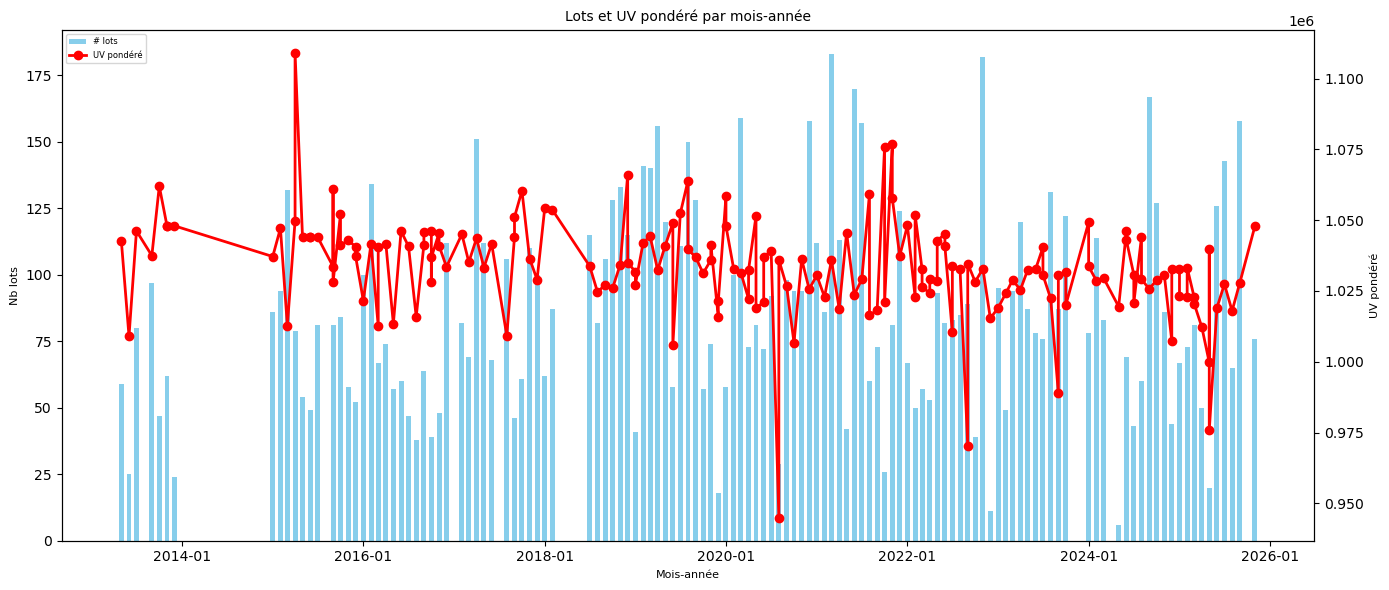

In [144]:
plot_campagnes_v4(campagnes)

nb elemtnts resume: 174


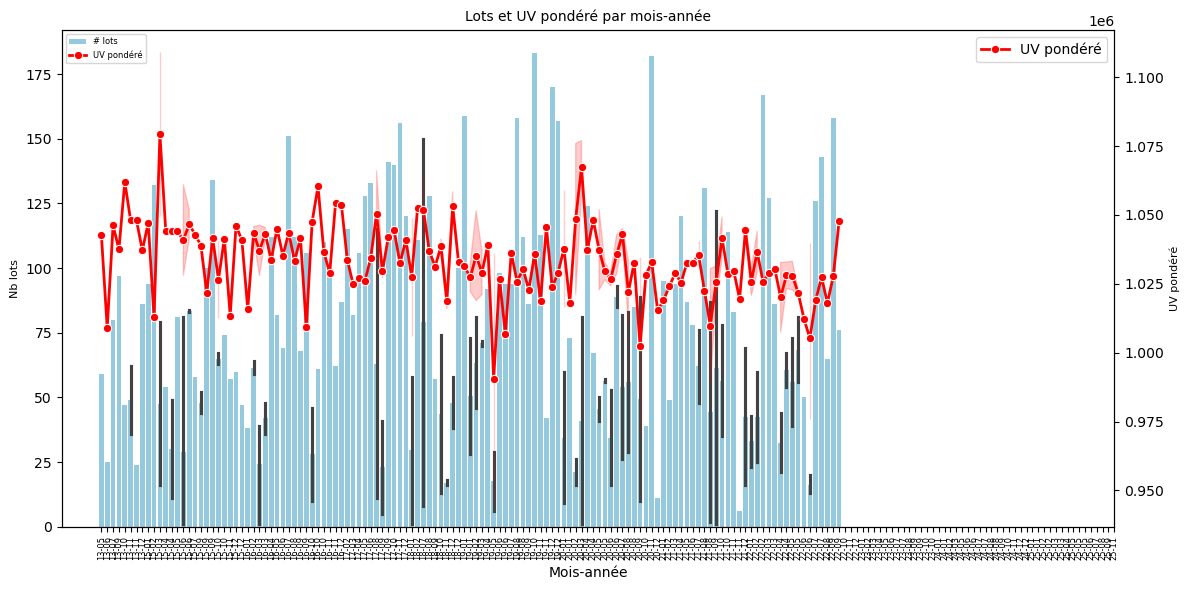

In [145]:
plot_campagnes_v2(campagnes)